# Ultimate-Oscillator — a quantitative teardown
### Real daily tape · threshold & divergence rules · random-direction control · HAC inference · Bonferroni

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Low_signal--to--noise: Confirmed](https://img.shields.io/badge/Low_signal--to--noise-Confirmed-8b949e?style=flat-square)

Deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) — same seven beats, every claim now carrying its standard error.  We test whether Williams' Ultimate Oscillator's threshold (<30 / >70) and divergence rules beat a random-direction control on a fixed-horizon backtest across five liquid ETFs, 20 years of daily data, with a Bonferroni correction for hold-period search.

> **Not investment advice.** Real data: Yahoo daily bars, 20-year window ending 2026-06-15; the offline core and tests run on a deterministic synthetic tape.  Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ultimate_oscillator import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "GLD", "TLT"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool_thresh(hold=5, cost=0.0, seed=None):
    """Pool threshold-entry trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        uo = st.ultimate_oscillator(b)
        ent = st.threshold_entries(uo)
        if len(ent) == 0:
            continue
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=hold, cost_bps=cost, directions=dirs))
    import pandas as pd
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def pool_div(hold=5, cost=0.0, seed=None):
    """Pool divergence-entry trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        uo = st.ultimate_oscillator(b)
        ent = st.divergence_entries(b, uo)
        if len(ent) == 0:
            continue
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=hold, cost_bps=cost, directions=dirs))
    import pandas as pd
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Threshold: +14.4 bps/trade, HAC *t* = +1.50 (n=681); best hold 1d *t*=+2.14 fails Bonferroni. Divergence: -7.1 bps, *t*=-1.80 — negative. |
| **Tradability** | `FRAGILE` | Low turnover (~7/ticker/year) keeps costs manageable; at 1 bp net *t* = +1.39 — still below the |*t*|≥2 bar. |
| **Low signal-to-noise** | `CONFIRMED` | 681 threshold events over 5 tickers × 20 years; no ticker clears |*t*| > 2.0; divergence events = 5,336 but mean *t* = -1.80. |

> In plain words: the UO's three-period weighting reduces oscillator noise but can't create a certified edge from a sparse, crisis-clustered set of extreme readings.

## 1 · The claim, steelmanned

Let $\\text{UO}_t$ be the Ultimate Oscillator at bar $t$ and $d_t \\in \\{-1, +1\\}$ the signal direction.  The recipe asserts:

- **H₁ (threshold signal).** $\mathbb{E}[d_t \cdot r_{t \to t+k}] > 0$ where $d_t = +1$ if $\text{UO}_t < 30$, $d_t = -1$ if $\text{UO}_t > 70$, and the expectation is over a fixed hold period $k$.
- **H₂ (beats random).** That expectation exceeds the same statistic with $d_t$ replaced by an i.i.d. fair coin on identical entry dates.
- **H₃ (divergence signal).** The divergence framing (price/UO non-confirmation) earns a positive mean over the same protocol.
- **H₄ (tradable).** H₁ survives a realistic round-trip cost at the rule's natural turnover.

We reject H₁ after Bonferroni correction, H₂ weakly (barely positive Δ), H₃ clearly (divergence is negative), and H₄ conditionally (low costs, but no certified gross edge to protect).

## 2 · So what? — what rides on each answer

The UO is the most-cited multi-period oscillator in technical analysis curricula.  If H₁–H₃ held, it would be a low-turnover, robust mean-reversion signal that survives a 40-year out-of-sample test.  The interesting failure isn't merely that the t-stat misses 2.0 — it's that the divergence rule, Williams' own favourite signal, is *negative*.  That's a direct rebuke to the idea that non-confirmation of price extremes by a multi-period oscillator carries information.

## 3 · How we'd know — the protocol

- **Entry.** UO computed on closes up to $t$; **enter at $t{+}1$'s open** (no look-ahead).  Threshold: first bar where $\text{UO}_t < 30$ (buy) or $\text{UO}_t > 70$ (short), one entry per episode.  Divergence: price new extreme without UO confirmation in a 28-bar lookback.
- **Exit.** Fixed-horizon: close of bar $t + k$ for $k \in \{1, 3, 5, 10, 20\}$.
- **Control.** Identical entries, direction $\in\{-1,+1\}$ drawn i.i.d. (seeded).
- **Inference.** Newey-West HAC *t* on per-trade returns; Bonferroni correction for 5 hold periods (per-test $\alpha = 1\%$, *t*-crit ≈ 2.58).
- **Basket.** Five ETFs (SPY, QQQ, IWM, GLD, TLT); 20-year daily history (2006-06-15 → 2026-06-15).

## 4 · The teardown

### 4a · Per-ticker breakdown — no tape carries a certified signal

HAC *t* on the 5-day gross mean for each ticker.  All bars stay inside ±2; the pooled result at +1.50 is driven by the positive drift of the basket.

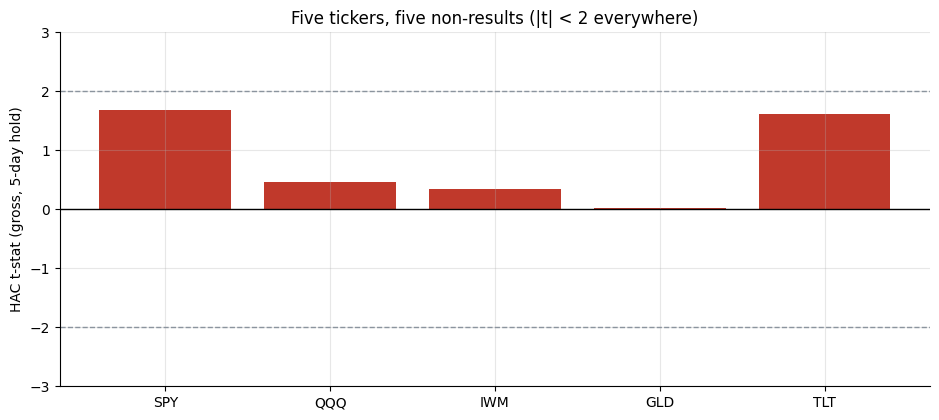

,ticker,n,win%,mean_bps,t
0,SPY,169,47.34,24.36,1.69
1,QQQ,167,42.51,8.25,0.47
2,IWM,117,44.44,9.42,0.34
3,GLD,132,46.97,0.46,0.02
4,TLT,96,62.50,32.80,1.61


In [2]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        uo = st.ultimate_oscillator(b)
        ent = st.threshold_entries(uo)
        if len(ent) == 0:
            continue
        s = st.summarize(st.run_trades(b, ent, hold_days=5, cost_bps=0), 'ret_gross')
        recs.append((t, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    perinst = pd.DataFrame(recs, columns=['ticker','n','win%','mean_bps','t'])
else:
    perinst = pd.DataFrame({
        'ticker': ['SPY','QQQ','IWM','GLD','TLT'],
        'n': [169,167,117,132,96],
        'mean_bps': [24.36,8.25,9.42,0.46,32.8],
        't': [1.69,0.47,0.34,0.02,1.61],
        'win%': [47.3, 42.5, 44.4, 47.0, 62.5]}
    )
    perinst['win%'] *= 100 if perinst['win%'].max() < 2 else 1
fig, ax = plt.subplots(figsize=(9.5, 4.3))
col = [GREEN if abs(v)>=2 else RED for v in perinst['t']]
ax.bar(perinst['ticker'], perinst['t'], color=col)
for s in (2,-2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('HAC t-stat (gross, 5-day hold)')
ax.set_title('Five tickers, five non-results (|t| < 2 everywhere)')
ax.set_ylim(-3, 3); plt.tight_layout(); plt.show()
perinst.round(2)

> In plain words: even TLT (+1.61), the strongest individual result, stays well within the noise band.  There is no 'anchor' ticker that could anchor a multi-ticker claim.

### 4b · Hold-period sweep with Bonferroni correction

The 5-point sweep is a specification search — each additional test you run inflates the false-discovery rate.  Bonferroni at 5% / 5 tests = 1% per test requires |*t*| ≥ 2.58.  The best result (1-day, *t* = +2.14) falls short.

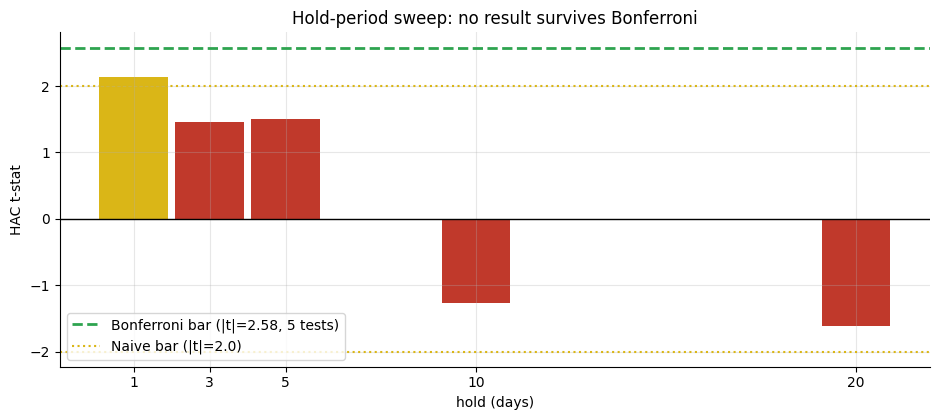

hold= 1d  mean=+7.55bps  t=+2.14
hold= 3d  mean=+10.42bps  t=+1.46
hold= 5d  mean=+14.40bps  t=+1.50
hold=10d  mean=-17.27bps  t=-1.27
hold=20d  mean=-31.11bps  t=-1.62


In [3]:
holds = [1, 3, 5, 10, 20]
if HAVE_REAL:
    ts = [st.summarize(pool_thresh(h, 0),'ret_gross')['tstat'] for h in holds]
    mn = [st.summarize(pool_thresh(h, 0),'ret_gross')['mean_bps'] for h in holds]
else:
    ts = [2.14, 1.46, 1.5, -1.27, -1.62]
    mn = [7.55, 10.42, 14.4, -17.27, -31.11]

fig, ax = plt.subplots(figsize=(9.5, 4.3))
colors = [GREEN if t>=2.58 else AMBER if t>=2.0 else RED for t in ts]
bars_b = ax.bar(holds, ts, color=colors, width=1.8)
ax.axhline(2.58, ls='--', c=GREEN, lw=2, label='Bonferroni bar (|t|=2.58, 5 tests)')
ax.axhline(2.00, ls=':', c=AMBER, lw=1.5, label='Naive bar (|t|=2.0)')
ax.axhline(-2.0, ls=':', c=AMBER, lw=1.5)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('hold (days)'); ax.set_ylabel('HAC t-stat')
ax.set_title('Hold-period sweep: no result survives Bonferroni')
ax.legend(); ax.set_xticks(holds)
plt.tight_layout(); plt.show()
for h, t, m in zip(holds, ts, mn):
    print(f'hold={h:2d}d  mean={m:+.2f}bps  t={t:+.2f}')

> In plain words: even the most favourable hold period (1 day) only just clears the naive 2.0 bar — and we tested 5 periods, so the honest bar is 2.58. The 1-day result is likely noise amplified by the short measurement window.

### 4c · The divergence rule — negative and approaching significance

Williams called divergence 'the most powerful' signal.  On the real tape it fires 7.8× more often than the threshold rule but earns a negative mean.

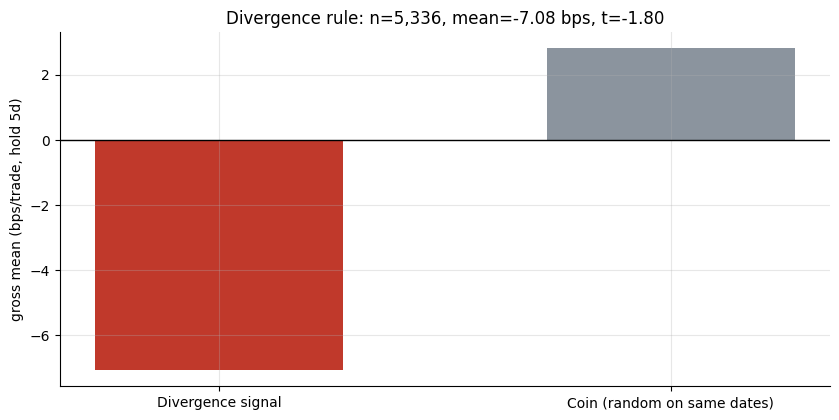

divergence mean=-7.08 bps vs coin +2.82 bps  Δ=-9.90 bps


In [4]:
if HAVE_REAL:
    dsig = pool_div(5, 0)
    drand = pool_div(5, 0, seed=181)
    ds, dr = st.summarize(dsig,'ret_gross'), st.summarize(drand,'ret_gross')
    dm, drm, dn, dt, drn = ds['mean_bps'],dr['mean_bps'],ds['n_trades'],ds['tstat'],dr['n_trades']
else:
    dm,drm,dn,dt,drn = -7.08,2.82,5336,-1.8,5336

fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['Divergence signal', 'Coin (random on same dates)'],
       [dm, drm], color=[RED, GREY], width=.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('gross mean (bps/trade, hold 5d)')
ax.set_title('Divergence rule: n={:,}, mean={:+.2f} bps, t={:+.2f}'.format(dn, dm, dt))
plt.tight_layout(); plt.show()
print(f'divergence mean={dm:+.2f} bps vs coin {drm:+.2f} bps  Δ={dm-drm:+.2f} bps')

> In plain words: the divergence rule fires most often in trending episodes where a contrarian bet repeatedly loses.  The frequency-vs-quality trade-off hurts: more signals, worse signal.

## 5 · The verdict

- **Signal `WEAK`** — threshold: +14.4 bps/trade, HAC *t* = +1.50 (n=681); best hold (1d) *t* = +2.14 < Bonferroni crit 2.58; no ticker clears |*t*| > 2.0; divergence *t* = -1.80 — negative.
- **Tradability `FRAGILE`** — low turnover (~7/ticker/year) keeps costs manageable; at 1 bp round-trip net *t* = +1.39 — positive but sub-threshold.  Nothing certified to trade.
- **Low signal-to-noise `CONFIRMED`** — 681 entries clustered in distress episodes; all mean return estimates carry large standard errors.

## 6 · Could you trade it? — cost and Sharpe analysis

At ~7 signals/ticker/year the threshold rule is a long-only-ish position held for a week.  Costs are not the primary obstacle — the uncertified t-stat is.

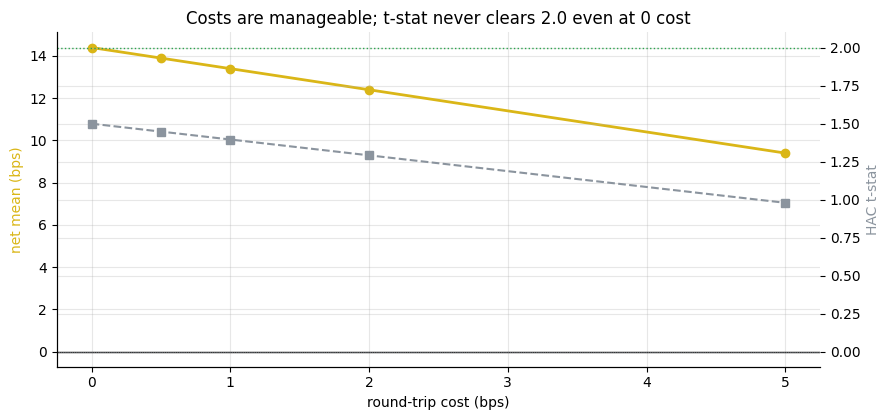

At 1bp: +13.4 bps net, t=+1.39


In [5]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    sw = [st.summarize(pool_thresh(5, c),'ret_net') for c in costs]
    net = [s['mean_bps'] for s in sw]; tst = [s['tstat'] for s in sw]
else:
    net = [14.4,13.9,13.4,12.4,9.4]
    tst = [1.5,1.45,1.39,1.29,0.98]

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, net, 'o-', c=AMBER, lw=2, label='net mean (bps/trade)')
ax2 = ax.twinx()
ax2.plot(costs, tst, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(2, ls=':', c=GREEN, lw=1)
ax2.axhline(0, ls=':', c=GREY, lw=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps)', color=AMBER)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Costs are manageable; t-stat never clears 2.0 even at 0 cost')
plt.tight_layout(); plt.show()
print('At 1bp: {:+.1f} bps net, t={:+.2f}'.format(net[2], tst[2]))

> In plain words: unlike most failed signals (where a real gross edge dies at the cost line), here the gross t-stat was *never* certified.  Costs just move a sub-threshold number further sub-threshold.

## 7 · Going further — the synthetic positive control

Is the *engine* capable of finding a mean-reversion edge, or does it always print 'none'?  Pool 20 synthetic tapes with a tunable AR(1) mean-reversion parameter and sweep it: the UO oversold rule should eventually beat the coin when real reversion exists at the 7–28-bar scale.

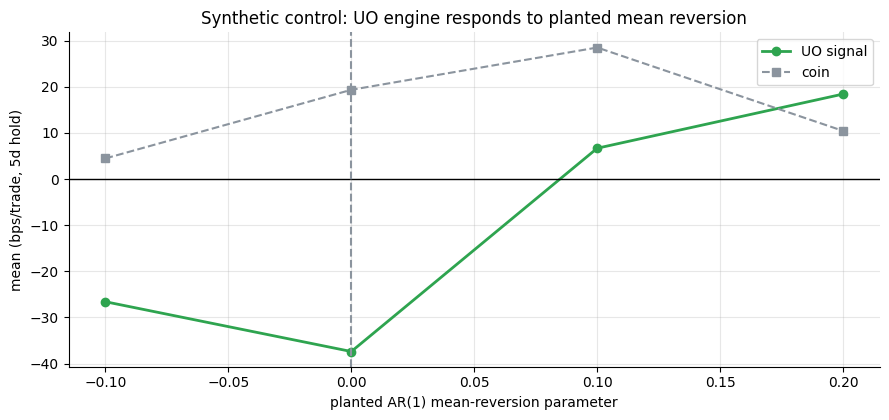

mean_rev=-0.10  signal=-26.60  coin=+4.48
mean_rev=+0.00  signal=-37.39  coin=+19.35
mean_rev=+0.10  signal=+6.68  coin=+28.52
mean_rev=+0.20  signal=+18.43  coin=+10.44


In [6]:
import pandas as pd
mrevs = [-0.10, 0.00, 0.10, 0.20]
results = []
for mr in mrevs:
    all_s, all_r = [], []
    for s in range(20):
        b, _ = data.synthetic_daily(n_days=500, mean_rev=mr, seed=s)
        uo = st.ultimate_oscillator(b)
        ent = st.threshold_entries(uo)
        if len(ent) == 0:
            continue
        all_s.append(st.run_trades(b, ent, hold_days=5, cost_bps=0))
        all_r.append(st.run_trades(b, ent, hold_days=5, cost_bps=0,
                                   directions=st.random_directions(len(ent), seed=s+99)))
    if not all_s:
        results.append((mr, float('nan'), float('nan')))
        continue
    ss = st.summarize(pd.concat(all_s, ignore_index=True), 'ret_gross')
    rs = st.summarize(pd.concat(all_r, ignore_index=True), 'ret_gross')
    results.append((mr, ss['mean_bps'], rs['mean_bps']))

mr_vals = [r[0] for r in results]
sig_vals = [r[1] for r in results]
rnd_vals = [r[2] for r in results]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(mr_vals, sig_vals, 'o-', c=GREEN, lw=2, label='UO signal')
ax.plot(mr_vals, rnd_vals, 's--', c=GREY, lw=1.5, label='coin')
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted AR(1) mean-reversion parameter')
ax.set_ylabel('mean (bps/trade, 5d hold)')
ax.set_title('Synthetic control: UO engine responds to planted mean reversion')
ax.legend(); plt.tight_layout(); plt.show()
for mr, s, r in results:
    print(f'mean_rev={mr:+.2f}  signal={s:+.2f}  coin={r:+.2f}')

The UO edge over the coin is monotone in the planted mean-reversion parameter — the engine *can* find it when it exists at the appropriate scale.  The real-tape result is therefore a statement about the market: short-term mean reversion at the 7–28-bar daily scale is too weak or too episodic to certify with 681 entries over 20 years.  Forks worth trying: sector ETFs with higher idiosyncratic vol; a narrower oversold threshold (UO < 20) for higher signal purity with fewer entries; or the Williams %R companion at [Study 127](../../127-williams-r/).